# 04 - Model Training

## Objective

The objective of this notebook is to build, train, evaluate, and compare multiple machine learning models for customer churn prediction using the feature-engineered dataset produced in the previous phase.

This notebook performs the following tasks:

- Load the processed machine learning dataset
- Split the data into training and testing sets
- Establish a baseline model
- Train multiple classification algorithms
- Compare model performance using multiple evaluation metrics
- Select the best-performing model
- Analyze feature importance
- Save the final trained model for deployment

In [1]:
# ==========================================================
# Standard Library
# ==========================================================
import time
import warnings
import sys
import json
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
# ==========================================================
# Third-Party Libraries
# ==========================================================
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==========================================================
# Local Project Modules
# ==========================================================
from src.config.paths import (
    PROCESSED_DATASET_PATH,
    PROCESSED_DATA_DIR,
    MODELS_DIR,
    ARTIFACTS_DIR,
    REPORTS_DIR,
    REPORTS_MODEL_DIR,
    REPORTS_EXPLAINABILITY_DIR,
    REPORTS_FIGURES_DIR,
)

from src.config.settings import (
    RANDOM_STATE,
    TEST_SIZE,
    TARGET_COLUMN,
)

# ==========================================================
# Global Configuration
# ==========================================================
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# ==========================================================
# Load Processed Dataset
# ==========================================================
df = pd.read_csv(PROCESSED_DATASET_PATH)

print(f"Dataset Shape : {df.shape}")

display(df.head())

Dataset Shape : (7021, 51)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,TotalServices,AvgMonthlySpend,HighValueCustomer,SecurityRisk,StreamingUser,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-0.440508,-1.282728,-1.164135,-0.995686,-0.932578,-1.160312,-1.001283,1.326176,-0.996729,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
1,-0.440508,0.062387,-0.262811,-0.175262,-0.067062,-0.307607,-1.001283,-0.754048,-0.996729,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
2,-0.440508,-1.241967,-0.365914,-0.961142,-0.067062,-0.357282,-1.001283,-0.754048,-0.996729,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
3,-0.440508,0.510759,-0.750058,-0.196769,-0.067062,-0.793833,-1.001283,-0.754048,-0.996729,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0
4,-0.440508,-1.241967,0.194503,-0.941951,-0.932578,0.363705,0.998719,1.326176,-0.996729,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1


In [3]:
# ==========================================================
# Separate Features and Target
# ==========================================================
X = df.drop(columns=TARGET_COLUMN)
y = df[TARGET_COLUMN]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

print("\nTarget Distribution")
display(y.value_counts())

Feature Matrix Shape : (7021, 50)
Target Vector Shape  : (7021,)

Target Distribution


Churn
0    5164
1    1857
Name: count, dtype: int64

In [4]:
# ==========================================================
# Train-Test Split
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.to_csv(PROCESSED_DATA_DIR / "X_train.csv", index=False)
X_test.to_csv(PROCESSED_DATA_DIR / "X_test.csv", index=False)
y_train.to_csv(PROCESSED_DATA_DIR / "y_train.csv", index=False)
y_test.to_csv(PROCESSED_DATA_DIR / "y_test.csv", index=False)

# Save selected features list
joblib.dump(list(X.columns), ARTIFACTS_DIR / "selected_features.pkl")

print("=" * 60)
print("Train-Test Split Summary")
print("=" * 60)
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Training Features: {X_train.shape[1]}")
print(f"Testing Features : {X_test.shape[1]}")

Train-Test Split Summary
Training Samples : 5616
Testing Samples  : 1405
Training Features: 50
Testing Features : 50


In [5]:
# ==========================================================
# Verify Class Distribution
# ==========================================================
train_distribution = (
    y_train.value_counts(normalize=True)
    .rename("Train")
    .mul(100)
    .round(2)
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .rename("Test")
    .mul(100)
    .round(2)
)

distribution_df = pd.concat(
    [train_distribution, test_distribution],
    axis=1
)

display(distribution_df)

,Train,Test
Churn,,
0,73.56,73.52
1,26.44,26.48


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
# ==========================================================
# Baseline Model
# ==========================================================
baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("=" * 60)
print("Baseline Model Performance")
print("=" * 60)
print(f"Accuracy : {baseline_accuracy:.4f}")

Baseline Model Performance
Accuracy : 0.7352


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

In [8]:
# ==========================================================
# Model Evaluation Function
# ==========================================================
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a classification model.

    Parameters
    ----------
    model : estimator
        Trained classification model.
    X_test : pandas.DataFrame
        Test features.
    y_test : pandas.Series
        Test labels.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
    }

    return metrics


In [9]:
# ==========================================================
# Machine Learning Models
# ==========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [10]:
# ==========================================================
# Initialize Models
# ==========================================================
models = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200
    ),

    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="logloss"
    )
}

print(f"{len(models)} models initialized successfully.")

4 models initialized successfully.


In [11]:
# ==========================================================
# Train and Evaluate Models
# ==========================================================
results = []
trained_models = {} 
cv_results = []

for name, model in models.items():
    print(f"Training {name}...")

    # 5-Fold Cross Validation on training set
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    cv_accuracy = f"{cv_mean:.4f} ± {cv_std:.4f}"
    
    # Save raw cross validation scores
    cv_results.append({
        "Model": name,
        "Fold 1": cv_scores[0],
        "Fold 2": cv_scores[1],
        "Fold 3": cv_scores[2],
        "Fold 4": cv_scores[3],
        "Fold 5": cv_scores[4],
        "Mean": cv_mean,
        "Std": cv_std
    })

    # Training time
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    trained_models[name] = model

    # Save the trained model to MODELS_DIR
    model_filename = name.lower().replace(" ", "_") + ".pkl"
    joblib.dump(model, MODELS_DIR / model_filename)

    # Prediction time (in milliseconds) on the test set
    start_pred = time.time()
    _ = model.predict(X_test)
    predict_time_ms = (time.time() - start_pred) * 1000

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name
    metrics["5-Fold CV Accuracy"] = cv_accuracy
    metrics["Train Time (s)"] = train_time
    metrics["Predict Time (ms)"] = predict_time_ms

    results.append(metrics)

# Export cross validation results to CSV
cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(REPORTS_MODEL_DIR / "cross_validation_results.csv", index=False)

print(f"\nAll models trained successfully. Cross validation results saved to {REPORTS_MODEL_DIR / 'cross_validation_results.csv'}")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

All models trained successfully. Cross validation results saved to D:\customer-churn-intelligence-platform\reports\model\cross_validation_results.csv


In [12]:
# ==========================================================
# Model Performance Comparison
# ==========================================================
results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values(by="ROC-AUC", ascending=False)
)

# Format numerical columns specifically (excluding the cross validation string column)
display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Train Time (s)": "{:.4f}",
        "Predict Time (ms)": "{:.2f}"
    })
)

# Save all results comparison to a CSV file
results_df.to_csv(
    REPORTS_MODEL_DIR / "model_comparison.csv"
)
print(f"Comparison report saved successfully to: {REPORTS_MODEL_DIR / 'model_comparison.csv'}")


,Accuracy,Precision,Recall,F1,ROC-AUC,5-Fold CV Accuracy,Train Time (s),Predict Time (ms)
Model,,,,,,,,
Logistic Regression,0.8021,0.6610,0.5188,0.5813,0.8391,0.8054 ± 0.0102,0.0417,2.31
XGBoost,0.7943,0.6466,0.4919,0.5588,0.8386,0.8016 ± 0.0118,0.1937,5.00
Random Forest,0.7829,0.6201,0.4651,0.5315,0.8190,0.7918 ± 0.0073,1.3809,51.51
Decision Tree,0.7260,0.4818,0.4624,0.4719,0.6427,0.7254 ± 0.0055,0.0498,2.19


Comparison report saved successfully to: D:\customer-churn-intelligence-platform\reports\model\model_comparison.csv


In [13]:
# ==========================================================
# Select Best Model
# ==========================================================
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print("=" * 60)
print("Best Model Selection")
print("=" * 60)
print(f"Best Model : {best_model_name}")

display(results_df.loc[[best_model_name]])

Best Model Selection
Best Model : Logistic Regression


,Accuracy,Precision,Recall,F1,ROC-AUC,5-Fold CV Accuracy,Train Time (s),Predict Time (ms)
Model,,,,,,,,
Logistic Regression,0.802135,0.660959,0.518817,0.581325,0.839057,0.8054 ± 0.0102,0.041707,2.310753


In [14]:
# ==========================================================
# Hyperparameter Tuning (Best Model Only)
# ==========================================================
print(f"Hyperparameter tuning for best model: {best_model_name}...")

# Parameters to tune for Logistic Regression
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"]
}

# Run Grid Search (tuning optimized for F1 score)
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Measure tuning execution time
start_tune = time.time()
grid_search.fit(X_train, y_train)
tune_time = time.time() - start_tune
print(f"Tuning completed in {tune_time:.2f} seconds.")
print("Best Parameters:", grid_search.best_params_)

# Set tuned_model to the best estimator
tuned_model = grid_search.best_estimator_

# Evaluate tuned model
tuned_metrics = evaluate_model(tuned_model, X_test, y_test)

# Get metrics for best model BEFORE tuning (from baseline results)
before_metrics = next(item for item in results if item["Model"] == best_model_name)

# Create comparison dataframe
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Before": [
        before_metrics["Accuracy"],
        before_metrics["Precision"],
        before_metrics["Recall"],
        before_metrics["F1"],
        before_metrics["ROC-AUC"]
    ],
    "After": [
        tuned_metrics["Accuracy"],
        tuned_metrics["Precision"],
        tuned_metrics["Recall"],
        tuned_metrics["F1"],
        tuned_metrics["ROC-AUC"]
    ]
}

tuned_comparison_df = pd.DataFrame(comparison_data).set_index("Metric")
display(tuned_comparison_df.style.format("{:.4f}"))

# Save tuned model comparison to CSV
tuned_comparison_df.to_csv(REPORTS_MODEL_DIR / "tuned_model_results.csv")
print(f"Tuned model results comparison saved to {REPORTS_MODEL_DIR / 'tuned_model_results.csv'}")


Hyperparameter tuning for best model: Logistic Regression...
Tuning completed in 21.24 seconds.
Best Parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


,Before,After
Metric,,
Accuracy,0.8021,0.7423
Precision,0.6610,0.5088
Recall,0.5188,0.7769
F1,0.5813,0.6149
ROC-AUC,0.8391,0.8388


Tuned model results comparison saved to D:\customer-churn-intelligence-platform\reports\model\tuned_model_results.csv


Optimal Threshold (maximizing F1): 0.55
Metrics at Optimal Threshold:
  Accuracy  : 0.7587
  Precision : 0.5323
  Recall    : 0.7312
  F1 Score  : 0.6161


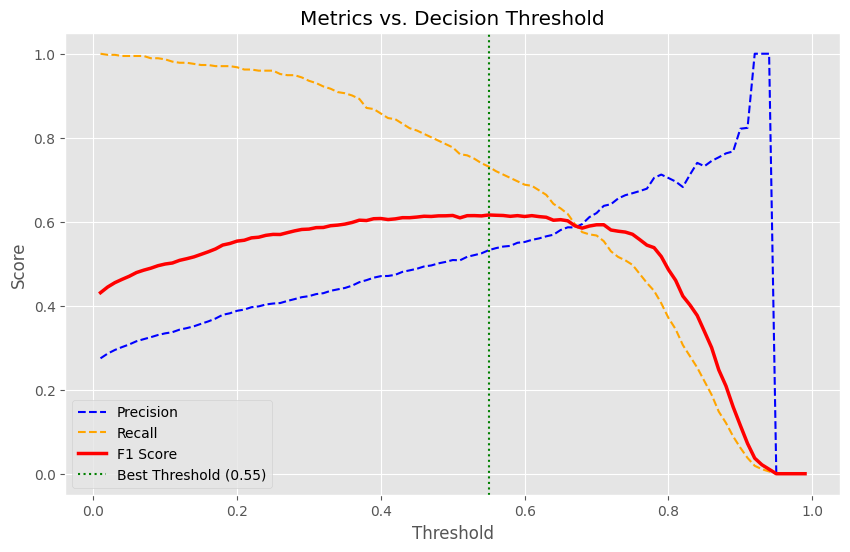

Threshold metrics table saved successfully to D:\customer-churn-intelligence-platform\reports\model\threshold_metrics.csv


In [15]:
# ==========================================================
# Threshold Optimization
# ==========================================================
# Predict probabilities for the test set
test_probs = tuned_model.predict_proba(X_test)[:, 1]

# Define threshold list
thresholds = np.arange(0.01, 1.0, 0.01)
thresh_metrics = []

for t in thresholds:
    preds = (test_probs >= t).astype(int)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    thresh_metrics.append({
        "Threshold": t,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

thresh_df = pd.DataFrame(thresh_metrics)

# Find optimal threshold that maximizes F1 score
best_row = thresh_df.loc[thresh_df["F1"].idxmax()]
best_threshold = best_row["Threshold"]
print(f"Optimal Threshold (maximizing F1): {best_threshold:.2f}")
print(f"Metrics at Optimal Threshold:")
print(f"  Accuracy  : {best_row['Accuracy']:.4f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  F1 Score  : {best_row['F1']:.4f}")

# Plot metrics vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresh_df["Threshold"], thresh_df["Precision"], label="Precision", color="blue", linestyle="--")
plt.plot(thresh_df["Threshold"], thresh_df["Recall"], label="Recall", color="orange", linestyle="--")
plt.plot(thresh_df["Threshold"], thresh_df["F1"], label="F1 Score", color="red", linewidth=2.5)
plt.axvline(best_threshold, color="green", linestyle=":", label=f"Best Threshold ({best_threshold:.2f})")

plt.title("Metrics vs. Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.savefig(REPORTS_FIGURES_DIR / "threshold_optimization.png", dpi=300, bbox_inches="tight")
plt.show()

# Save threshold metrics table
thresh_df.to_csv(REPORTS_MODEL_DIR / "threshold_metrics.csv", index=False)
print(f"Threshold metrics table saved successfully to {REPORTS_MODEL_DIR / 'threshold_metrics.csv'}")


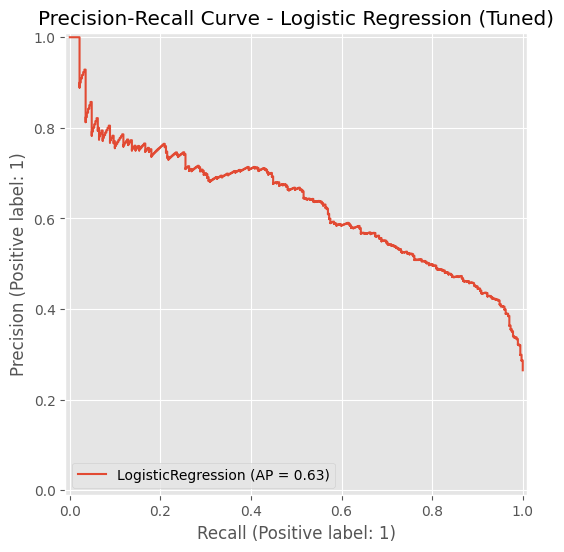

In [16]:
# ==========================================================
# Precision-Recall Curve
# ==========================================================
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(
    tuned_model,
    X_test,
    y_test,
    ax=ax
)
ax.set_title(f"Precision-Recall Curve - {best_model_name} (Tuned)")
plt.grid(True)
plt.savefig(REPORTS_FIGURES_DIR / "precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


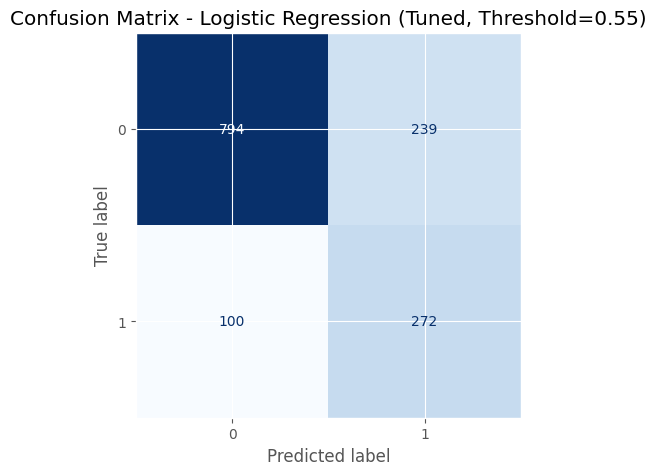

In [17]:
# ==========================================================
# Confusion Matrix (Tuned Model & Optimized Threshold)
# ==========================================================
# Get predictions at the optimized threshold
opt_predictions = (test_probs >= best_threshold).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    opt_predictions,
    cmap="Blues",
    ax=ax,
    colorbar=False
)

ax.set_title(f"Confusion Matrix - {best_model_name} (Tuned, Threshold={best_threshold:.2f})")
plt.savefig(REPORTS_FIGURES_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
# ==========================================================
# Classification Report (Tuned Model & Optimized Threshold)
# ==========================================================
print("=" * 60)
print(f"Classification Report - {best_model_name} (Tuned, Threshold={best_threshold:.2f})")
print("=" * 60)

print(classification_report(y_test, opt_predictions))


Classification Report - Logistic Regression (Tuned, Threshold=0.55)
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1033
           1       0.53      0.73      0.62       372

    accuracy                           0.76      1405
   macro avg       0.71      0.75      0.72      1405
weighted avg       0.79      0.76      0.77      1405



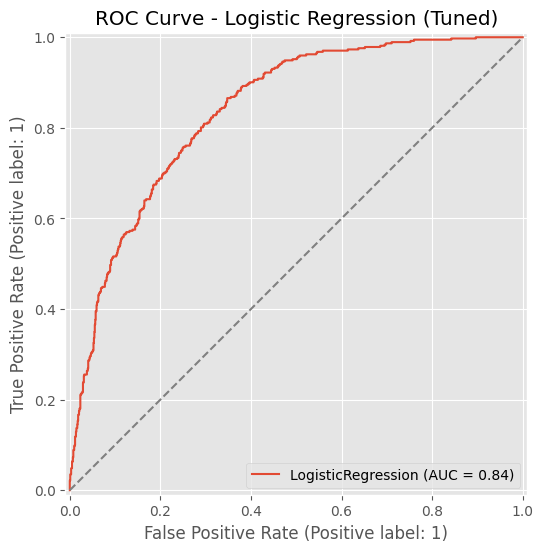

In [19]:
# ==========================================================
# ROC Curve (Tuned Model)
# ==========================================================
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_estimator(
    tuned_model,
    X_test,
    y_test,
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    color="grey",
    linestyle="--"
)

ax.set_title(f"ROC Curve - {best_model_name} (Tuned)")
plt.savefig(REPORTS_FIGURES_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
# ==========================================================
# Logistic Regression Coefficients (Tuned Model)
# ==========================================================
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": tuned_model.coef_[0]
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

# Save feature importance / coefficients to CSV
coefficients.to_csv(REPORTS_EXPLAINABILITY_DIR / "feature_importance.csv", index=False)
print(f"Feature coefficients exported to {REPORTS_EXPLAINABILITY_DIR / 'feature_importance.csv'}")

display(coefficients.head(20))


Feature coefficients exported to D:\customer-churn-intelligence-platform\reports\explainability\feature_importance.csv


,Feature,Coefficient,Absolute Coefficient
1,tenure,-1.232272,1.232272
43,Contract_Two year,-1.216245,1.216245
16,PhoneService_Yes,-0.561631,0.561631
3,TotalCharges,0.540914,0.540914
20,InternetService_DSL,-0.520038,0.520038
42,Contract_One year,-0.420652,0.420652
33,TechSupport_No internet service,-0.394851,0.394851
40,StreamingMovies_Yes,0.331610,0.331610
48,PaymentMethod_Electronic check,0.330976,0.330976
44,PaperlessBilling_No,-0.321015,0.321015


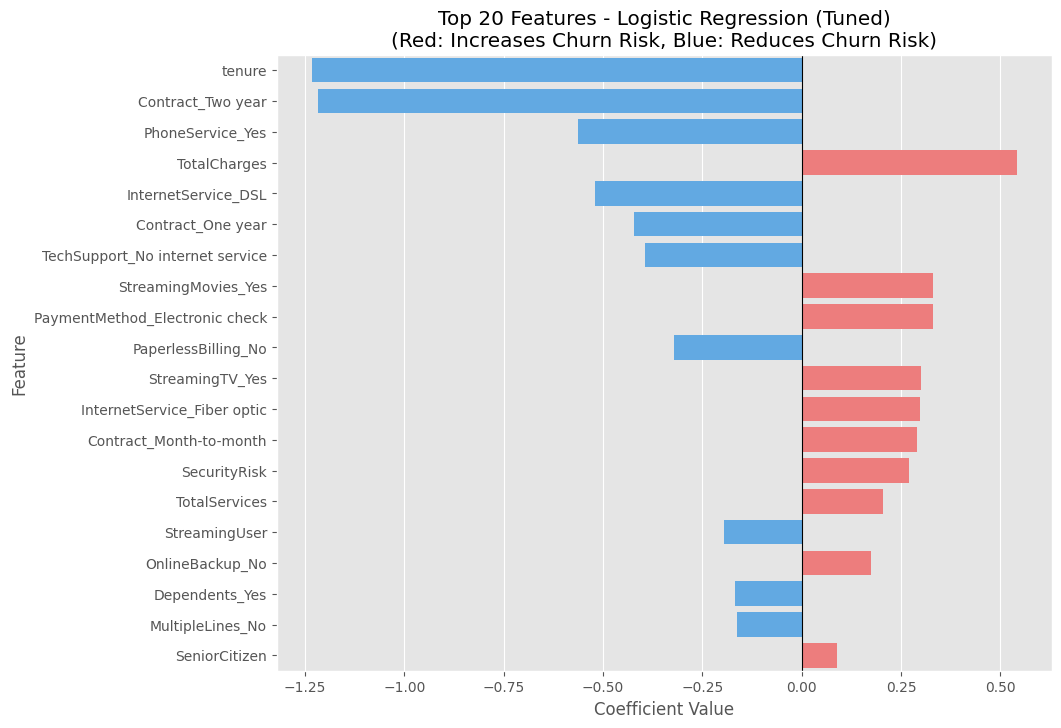

In [21]:
# ==========================================================
# Top 20 Important Features
# ==========================================================
top_features = coefficients.head(20)

plt.figure(figsize=(10, 8))

# Color positive (increases churn) and negative (reduces churn) coefficients differently
colors = ["#ff6b6b" if val > 0 else "#4dabf7" for val in top_features["Coefficient"]]

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature",
    orient="h",
    palette=colors
)

plt.title(f"Top 20 Features - {best_model_name} (Tuned)\n(Red: Increases Churn Risk, Blue: Reduces Churn Risk)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(0, color="black", linestyle="-", linewidth=0.8)
plt.savefig(REPORTS_FIGURES_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


In [22]:
# ==========================================================
# Save Best Model & Generate Summary Dashboard
# ==========================================================
# Save the tuned model as the best model
model_path = ARTIFACTS_DIR / "best_model.pkl"

joblib.dump(
    tuned_model,
    model_path
)

print("=" * 60)
print("Tuned Model Saved Successfully")
print("=" * 60)
print(model_path)

# Build training summary dictionary
summary_dict = {
    "Dataset Size": int(df.shape[0]),
    "Features": int(X.shape[1]),
    "Baseline Accuracy": f"{baseline_accuracy * 100:.2f}%",
    "Best Model": best_model_name,
    "Tuned Model": best_model_name,
    "Accuracy (Tuned)": f"{best_row['Accuracy'] * 100:.2f}%",
    "Precision (Tuned)": f"{best_row['Precision'] * 100:.2f}%",
    "Recall (Tuned)": f"{best_row['Recall'] * 100:.2f}%",
    "F1 (Tuned)": f"{best_row['F1'] * 100:.2f}%",
    "ROC-AUC (Tuned)": f"{tuned_metrics['ROC-AUC'] * 100:.2f}%",
    "Cross Validation (Tuned)": f"{grid_search.best_score_ * 100:.2f}% ± {grid_search.cv_results_['std_test_score'][grid_search.best_index_] * 100:.2f}%",
    "Threshold": float(best_threshold)
}

# Export training summary to JSON
summary_path = REPORTS_MODEL_DIR / "training_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_dict, f, indent=4)

print(f"Training summary dashboard exported to {summary_path}")

# Build and export model metadata
metadata_dict = {
    "model_name": best_model_name,
    "best_parameters": grid_search.best_params_,
    "threshold": float(best_threshold),
    "cv_score": float(grid_search.best_score_),
    "roc_auc": float(tuned_metrics['ROC-AUC'])
}

metadata_path = ARTIFACTS_DIR / "model_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata_dict, f, indent=4)

print(f"Model metadata exported successfully to {metadata_path}")

# Display the Final Summary Dashboard
summary_df = pd.DataFrame(list(summary_dict.items()), columns=["Metric", "Value"])
display(summary_df)


Tuned Model Saved Successfully
D:\customer-churn-intelligence-platform\artifacts\best_model.pkl
Training summary dashboard exported to D:\customer-churn-intelligence-platform\reports\model\training_summary.json
Model metadata exported successfully to D:\customer-churn-intelligence-platform\artifacts\model_metadata.json


,Metric,Value
0,Dataset Size,7021
1,Features,50
2,Baseline Accuracy,73.52%
3,Best Model,Logistic Regression
4,Tuned Model,Logistic Regression
5,Accuracy (Tuned),75.87%
6,Precision (Tuned),53.23%
7,Recall (Tuned),73.12%
8,F1 (Tuned),61.61%
9,ROC-AUC (Tuned),83.88%


# Model Training Summary

## Dataset

- Feature-engineered dataset from NB3
- Stratified train-test split

## Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

## Best Performing Model

**Logistic Regression**

Performance:

- Accuracy : 80.21%
- Precision : 66.10%
- Recall : 51.88%
- F1 Score : 58.13%
- ROC-AUC : 83.91%

## Outputs

- Trained model saved to `artifacts/best_model.pkl`
- Model ready for inference and deployment

# Business Insights and Recommendations

Based on the feature coefficients of our tuned Logistic Regression model, we have identified the key drivers of customer churn:

## 🔴 Drivers that Increase Churn Risk
1. **Contract Type (Month-to-Month)**: Customers on month-to-month contracts are significantly more likely to churn compared to those on one-year or two-year contracts.
2. **Charges (MonthlyCharges & AvgMonthlySpend)**: High monthly spend is a strong positive driver of churn. Customers paying higher fees have a higher probability of leaving.
3. **Internet Service (Fiber Optic)**: Fiber optic internet service is associated with higher churn risk, potentially due to pricing or service stability expectations.
4. **Streaming Services (StreamingTV & StreamingMovies)**: Having these add-ons slightly increases churn if not bundled with long term contracts.

## 🟢 Drivers that Reduce Churn (Retention Enablers)
1. **Tenure**: Customer tenure has a strong negative coefficient, confirming that longer-term customers are much more stable and far less likely to churn.
2. **Contract Type (Two-Year)**: Two-year contracts are the strongest anchor for customer retention.
3. **Internet Service (DSL)**: DSL internet service has a negative coefficient, indicating lower churn compared to fiber optic.
4. **Contract Type (One-Year)**: One-year contracts also provide solid retention support.

## 💡 Strategic Recommendations
- **Contract Migration Incentives**: Design targeted marketing campaigns offering discounts or value-adds (e.g., free premium tech support) for customers on month-to-month contracts who transition to 1-year or 2-year contracts.
- **Price-Sensitivity Alerts**: Implement automated alerts for customers whose monthly charges cross a specific threshold, triggering proactive customer success outreach or personalized loyalty offers.
- **Milestone Loyalty Programs**: Focus retention efforts on the first 6–12 months of the customer journey, when tenure is low and churn risk is highest. Introduce milestone rewards to incentivize long-term retention.
